# RANBP17_exp — **Tile-level** pixel colocalization of TDP-43 in RANBP17

## Goal: test whether TDP-43 is enriched in RANBP17-positive pixels (P(TDP+ | RANBP17+)) above what is expected by chance — computed on **preprocessed NPY tiles** instead of full TIFF sites.

Adapted from `pixel_level_colocalization_RANBP17_TDP43.ipynb` (site-level). Differences:
- Reads **preprocessed tiles** from `input/images/processed/RANBP17_exp/<batch>/<cell_line>/<condition>/<marker>/<file>.npy`
  (shape `[n_tiles, 100, 100, 2]`, **already rescaled to [0,1]**; channel 0 = marker, channel 1 = DAPI).
- The processed layout has **no `panel` / `rep` directory** — both are encoded in the filename
  (`rep2_r03c04f07-ch1t1_panelA_iW11_processed.npy`) and parsed from it.
- RANBP17 (`ch1`) and TDP-43 (`ch3`) tiles of the same site share one nucleus segmentation, so
  `tile_index i` corresponds across markers → pairing is by `(batch, cell_line, condition, rep, site, tile_index)`.
- **No rescaling** (tiles are pre-processed). **No fixed-threshold option** — adaptive `mean+K·sd` only, to stay close to the original.
- `PANELS` / `REPS` are optional global filters (set to `None` to disable).

Pipeline:
1. List tile paths per batch/cell_line/condition/marker; explode each NPY into one row per tile.
2. For each tile, pair RANBP17 (ch1) with TDP-43 (ch3) and compute `fraction_overlap` (real) and `fraction_overlap_rotated` (TDP rotated 90° as the spatial-random null).
3. Plot distributions; paired Wilcoxon real vs rotated.
4. Per-condition / per-rep aggregates and reproducibility plots; effect-size report (runs only when ≥2 batches are present).

## Imports

In [37]:
import os
import sys
import re
import numpy as np
import pandas as pd
%matplotlib inline

from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

os.environ['NOVA_HOME'] = '/home/projects/hornsteinlab/Collaboration/NOVA'
sys.path.insert(1, os.getenv('NOVA_HOME'))
print(f"NOVA_HOME: {os.getenv('NOVA_HOME')}")

# Reuse the shared per-marker colormaps for the mask/overlap visualization.
from tools.channels_colocalization.pixel_colocalization_utils import (
    cmap_black_to_red, cmap_black_to_green, cmap_black_to_blue,
)

# Effect-size report (only meaningful with >1 batch).
try:
    from cell_profiler.code.cp_effect_size_utils import run_analysis_generate_report
    HAS_EFFECT_SIZE_REPORT = True
except Exception as _e:
    HAS_EFFECT_SIZE_REPORT = False
    print(f"run_analysis_generate_report not available: {_e}")

%load_ext autoreload
%autoreload 2

NOVA_HOME: /home/projects/hornsteinlab/Collaboration/NOVA
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Globals

In [ ]:
# RANBP17_exp preprocessed TILES (NPY, already rescaled to [0,1], shape [n_tiles, 100, 100, 2]).
MAIN_DATA_PATH = "/home/projects/hornsteinlab/Collaboration/NOVA/input/images/processed/RANBP17_exp"

# Flexible batch list. The effect-size model (Step 3) runs only if >=2 batches are present.
BATCHES = ['batch3'] # ['batch1', 'batch2', 'batch3']
CELL_LINES = ['iW11']
CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated']
CONTROL_CONDITIONS = ['control-179', 'control-180', 'untreated']
KD_CONDITIONS = ['tardp-kd', 'ranbp17-kd', 'both-kd']

# Pairwise KD-vs-control contrasts (Step 3): each KD tested separately against each control.
# 'untreated' is excluded as a comparator (anomalous: near-null mean, CV ~0.87).
PAIRWISE_CONTROLS = ['control-179', 'control-180']
KD_VS_CONTROL_PAIRS = [(kd, ctrl) for kd in KD_CONDITIONS for ctrl in PAIRWISE_CONTROLS]

# Optional filters parsed from the filename. Set to None to disable a filter.
PANELS = ['panelA']          # e.g. ['panelA'] or None
REPS   = ['rep4', 'rep5', 'rep6', 'rep7', 'rep8'] #['rep2']                # e.g. ['rep1', 'rep2'] or None (all reps)

CHANNEL_MAP = {
    'RANBP17': 'ch1',
    'DAPI':    'ch2',
    'TDP-43':  'ch3',
}

# Adaptive threshold k (mean + k*sd) per marker.
MASK_K_MAP = {
    'RANBP17': 1.25,
    'TDP-43':  1.25,
    'DAPI':    1.75,
}

# Rotation null: average the conditional overlap over these 90-deg rotations of the
# partner image (more robust than a single 90-deg rotation).
ROTATION_KS = (1, 2, 3)

# Per-marker colormaps for the visualization (reused from the shared util).
MARKER_CMAP = {
    'RANBP17': cmap_black_to_red,
    'TDP-43':  cmap_black_to_green,
    'DAPI':    cmap_black_to_blue,
}

# Channel and marker layout for this experiment.
ANCHOR_MARKER   = 'TDP-43'
PARTNER_MARKER  = 'RANBP17'
ANCHOR_CHANNEL  = CHANNEL_MAP[ANCHOR_MARKER]    # RANBP17 = ch1
PARTNER_CHANNEL = CHANNEL_MAP[PARTNER_MARKER]   # TDP-43  = ch3
ANCHOR_MASK_K   = MASK_K_MAP[ANCHOR_MARKER]
PARTNER_MASK_K  = MASK_K_MAP[PARTNER_MARKER]

thresholds = f"ancK{ANCHOR_MASK_K}_partK{PARTNER_MASK_K}"
batches_tag = "-".join(BATCHES)
# Output directory for figures + intermediate CSVs (under a 'tiles' subfolder).
save_path = (f'/home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/'
             f'co-localization_and_KD/colocalization_outputs/tiles/{batches_tag}/'
             f'{ANCHOR_MARKER}_{PARTNER_MARKER}/{thresholds}')
os.makedirs(save_path, exist_ok=True)
print("save_path:", save_path)

# Font (falls back silently if missing).
FONT_PATH = '/home/projects/hornsteinlab/sagyk/anaconda3/envs/nova/fonts/arial.ttf'
from matplotlib import font_manager as fm
import matplotlib
if os.path.exists(FONT_PATH):
    fm.fontManager.addfont(FONT_PATH)
    matplotlib.rcParams['font.family'] = 'Arial'
plt.rcParams.update({'font.size': 8})

save_path: /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/tiles/batch3/TDP-43_RANBP17/ancK1.25_partK1.25


## Helpers (tile paths → per-tile dataframe, RANBP17/TDP matching)

The shared `load_tiles_to_dataframe` / `match_tiles_and_score_fraction_overlap` in
`pixel_colocalization_utils.py` hard-code DCP1A/TDP43 markers, a positional 16-component path
unpack, an `s\d+` site regex, and the limited threshold-K set. We rewrite them locally to:
- parse the processed RANBP17_exp path with negative indexing (no panel/rep dirs);
- parse `rep` / `site` / `panel` from the **filename** and filter by `PANELS` / `REPS`;
- use arbitrary-K adaptive thresholds and the `ANCHOR`/`PARTNER` marker pair.

In [ ]:
_GILIWO_UTILS = '/home/projects/hornsteinlab/giliwo/NOVA/tools/channels_colocalization'
if _GILIWO_UTILS not in sys.path:
    sys.path.insert(0, _GILIWO_UTILS)

from tile_colocalization_utils import (
    list_tile_paths, _parse_filename, load_tiles_to_dataframe,
    get_threshold, method_for_marker, score_fraction_overlap,
    _score_file_pair, match_tiles_and_score,
    _pretty, _rgb_overlay, _mask_overlay, show_sample_tiles,
    melt_coloc_df, p_to_stars, draw_coloc_panel,
)

## Step 1: List tile paths and build the per-tile DataFrame

Eager: each NPY is exploded into one row per tile (the tile array is kept in `tile_data`).

In [40]:
paths = list_tile_paths(
    input_dir=MAIN_DATA_PATH,
    batches=BATCHES,
    cell_lines=CELL_LINES,
    conditions=CONDITIONS,
    markers=[ANCHOR_MARKER, PARTNER_MARKER],  # only the two we need; skip DAPI
)
df = load_tiles_to_dataframe(paths, panels=PANELS, reps=REPS)
df.head()

Listed 4077 NPY tile files (batches=['batch3'], conditions=['tardp-kd', 'ranbp17-kd', 'both-kd', 'control-179', 'control-180', 'untreated'], markers=['TDP-43', 'RANBP17']).
Built per-file metadata DataFrame: 4077 NPY files. Markers: ['RANBP17', 'TDP-43']. panels=['panelA'], reps=['rep1', 'rep2', 'rep4', 'rep5', 'rep6', 'rep7', 'rep8'].


,path,batch,cell_line,panel,condition,rep,marker,filename,site
0,/home/projects/hornsteinlab/Collaboration/NOVA...,batch3,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c02f01-ch3t1_panelA_iW11_processed.npy,r02c02f01
1,/home/projects/hornsteinlab/Collaboration/NOVA...,batch3,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c02f02-ch3t1_panelA_iW11_processed.npy,r02c02f02
2,/home/projects/hornsteinlab/Collaboration/NOVA...,batch3,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c02f03-ch3t1_panelA_iW11_processed.npy,r02c02f03
3,/home/projects/hornsteinlab/Collaboration/NOVA...,batch3,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c02f04-ch3t1_panelA_iW11_processed.npy,r02c02f04
4,/home/projects/hornsteinlab/Collaboration/NOVA...,batch3,iW11,panelA,tardp-kd,rep1,TDP-43,rep1_r02c02f05-ch3t1_panelA_iW11_processed.npy,r02c02f05


In [41]:
# Sanity: per-batch x per-condition x per-rep file counts per marker (tiles resolved lazily in match_tiles_and_score).
df.groupby(['batch', 'condition', 'rep', 'marker']).size().unstack(fill_value=0)

marker                   RANBP17  TDP-43
batch  condition   rep                  
batch3 both-kd     rep1       47      47
                   rep2       49      49
                   rep4       45      45
                   rep5       46      46
                   rep6       49      49
                   rep7       46      46
                   rep8       47      47
       control-179 rep1       49      49
                   rep2       49      49
                   rep4       49      49
                   rep5       49      49
                   rep6       49      49
                   rep7       49      49
                   rep8       49      49
       control-180 rep1       49      49
                   rep2       49      49
                   rep4       49      49
                   rep5       49      49
                   rep6       49      49
                   rep7       49      49
                   rep8       49      49
       ranbp17-kd  rep1       49      49
                   rep2       49      49
                   rep4       49      49
                   rep5       49      49
                   rep6       49      49
                   rep7       49      49
                   rep8       49      48
       tardp-kd    rep1       49      49
                   rep2       48      48
                   rep4       49      49
                   rep5       48      48
                   rep6       49      49
                   rep7       49      49
                   rep8       49      49
       untreated   rep1       49      49
                   rep2       47      47
                   rep4       49      49
                   rep5       49      49
                   rep6       48      48
                   rep7       49      49
                   rep8       49      49

In [ ]:
# _pretty, _rgb_overlay, _mask_overlay, show_sample_tiles — imported from tile_colocalization_utils.

## Step 2: Compute `fraction_overlap` per tile

Anchor = RANBP17 (ch1, channel index 0 of its NPY). Partner = TDP-43 (ch3). For each tile we compute
P(TDP+ | RANBP17+) on the real tile and on the 90°-rotated TDP tile (null). Thresholds: `mean + k·sd` per marker.

In [ ]:
df_overlap = match_tiles_and_score(
    df,
    anchor_marker=ANCHOR_MARKER,
    partner_marker=PARTNER_MARKER,
    mask_k_map=MASK_K_MAP,
)
df_overlap.head()

In [ ]:
output_dir = os.path.join(save_path, 'sample_tiles')
os.makedirs(output_dir, exist_ok=True)
show_sample_tiles(
    df_overlap,
    anchor_marker=ANCHOR_MARKER,
    partner_marker=PARTNER_MARKER,
    mask_k_map=MASK_K_MAP,
    anchor_cmap=MARKER_CMAP.get(ANCHOR_MARKER),
    partner_cmap=MARKER_CMAP.get(PARTNER_MARKER),
    n_per_condition=2,
    output_dir=output_dir,
)

In [45]:
csv_path = os.path.join(save_path, f'{ANCHOR_MARKER}_{PARTNER_MARKER}_fraction_overlap_tiles.csv')
df_overlap.to_csv(csv_path, index=False)
print('Saved scored per-tile DataFrame to', csv_path)

Saved scored per-tile DataFrame to /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/tiles/batch3/TDP-43_RANBP17/ancK1.25_partK1.25/TDP-43_RANBP17_fraction_overlap_tiles.csv


## Plot real vs rotated fraction_overlap distributions

Expect a clear right-shift of the real distribution if RANBP17 and TDP-43 colocalize above chance.

After dropna: 26845/26845 tiles have scores.


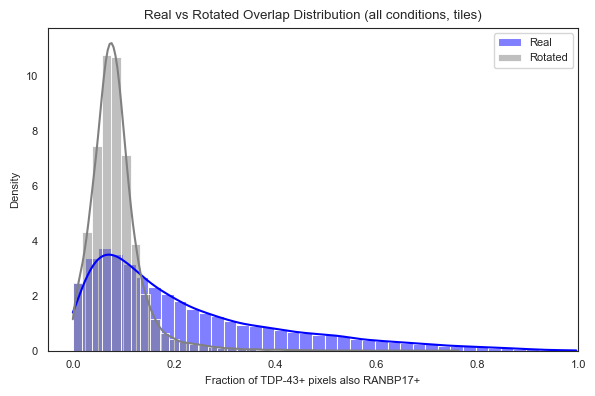

In [46]:
df_clean = df_overlap.dropna(subset=['fraction_overlap', 'fraction_overlap_rotated']).copy()
df_clean['fraction_overlap']         = df_clean['fraction_overlap'].astype(float)
df_clean['fraction_overlap_rotated'] = df_clean['fraction_overlap_rotated'].astype(float)
print(f"After dropna: {len(df_clean)}/{len(df_overlap)} tiles have scores.")

plt.figure(figsize=(6, 4))
sns.histplot(df_clean['fraction_overlap'],         label='Real',    color='blue', kde=True, stat='density', bins=40)
sns.histplot(df_clean['fraction_overlap_rotated'], label='Rotated', color='gray', kde=True, stat='density', bins=40)
plt.xlabel(f'Fraction of {ANCHOR_MARKER}+ pixels also {PARTNER_MARKER}+')
plt.ylabel('Density')
plt.title('Real vs Rotated Overlap Distribution (all conditions, tiles)')
plt.legend()
plt.xlim(-0.05, 1)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'fraction_overlap_{ANCHOR_MARKER}_{PARTNER_MARKER}_real_vs_rotated_all_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

## Summary statistics — aggregate by condition / rep

In [47]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch3,both-kd,rep1,0.261135,0.211921,506
1,batch3,both-kd,rep2,0.244448,0.228560,385
2,batch3,both-kd,rep4,0.333842,0.222952,379
3,batch3,both-kd,rep5,0.291778,0.222730,513
4,batch3,both-kd,rep6,0.236793,0.195609,543
5,batch3,both-kd,rep7,0.258854,0.223192,413
6,batch3,both-kd,rep8,0.160039,0.143799,432
7,batch3,control-179,rep1,0.314113,0.226701,574
8,batch3,control-179,rep2,0.305872,0.240088,436
9,batch3,control-179,rep4,0.214911,0.192646,538


In [48]:
df_clean.groupby(['batch', 'condition', 'rep'])['fraction_overlap_rotated'].agg(['mean', 'std', 'count']).reset_index()

,batch,condition,rep,mean,std,count
0,batch3,both-kd,rep1,0.082431,0.056149,506
1,batch3,both-kd,rep2,0.085222,0.066088,385
2,batch3,both-kd,rep4,0.087985,0.060247,379
3,batch3,both-kd,rep5,0.089520,0.058858,513
4,batch3,both-kd,rep6,0.092482,0.056558,543
5,batch3,both-kd,rep7,0.087869,0.056788,413
6,batch3,both-kd,rep8,0.080978,0.039851,432
7,batch3,control-179,rep1,0.079934,0.061782,574
8,batch3,control-179,rep2,0.086955,0.069904,436
9,batch3,control-179,rep4,0.086613,0.055915,538


## Step 3: Pairwise KD-vs-control effect-size models

Each KD condition is tested **separately** against each control in `KD_VS_CONTROL_PAIRS`
(e.g. `tardp-kd` vs `control-179`, `ranbp17-kd` vs `control-179`, …), rather than pooling all
KDs vs all controls. Per pair we fit `fraction_overlap ~ C(group)` with a random intercept for
batch and rep nested within batch (mixed model), falling back to replicate-level OLS on
per-(batch, rep) means if the variance components are singular. Reference = the control, so
**β > 0 means higher colocalization under KD**. p-values are FDR-corrected (Benjamini–Hochberg)
across all pairs, and effect sizes ±95% CI are shown as a forest plot. Needs ≥2 batches.

In [49]:
# ---- Step 3: Pairwise KD-vs-control, one model per (KD, control) pair ----
# KD-vs-control is a BETWEEN-group contrast, so tiles within a rep are pseudoreplicates: the
# replicate (batch, rep) is the unit. Per pair we fit
#   fraction_overlap ~ C(group), random intercept for batch + rep nested within batch,
# control as the reference level (so beta > 0 = HIGHER colocalization under KD).
# Fallback (singular variance components): OLS on per-(batch, rep) means with batch as a fixed
# block. p-values are FDR-corrected across pairs. Needs >=2 batches.
import statsmodels.formula.api as smf
import warnings
from statsmodels.stats.multitest import multipletests

COEF = 'C(group)[T.KD]'

def test_kd_vs_control(data, kd_cond, ctrl_cond):
    """Fit one KD-vs-control contrast; return a result row (beta, CI, p, model, counts)."""
    sub = data[data['condition'].isin([kd_cond, ctrl_cond])].copy()
    n_kd, n_ctrl = (sub['condition'] == kd_cond).sum(), (sub['condition'] == ctrl_cond).sum()
    row = {'kd': kd_cond, 'control': ctrl_cond, 'n_tiles_kd': int(n_kd),
           'n_tiles_ctrl': int(n_ctrl), 'n_batches': sub['batch'].nunique(),
           'beta': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan, 'pval': np.nan, 'model': 'skipped'}
    if row['n_batches'] < 2 or n_kd == 0 or n_ctrl == 0:
        return row
    sub['group'] = np.where(sub['condition'] == kd_cond, 'KD', 'control')
    sub['group'] = pd.Categorical(sub['group'], categories=['control', 'KD'])  # ref = control
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            md = smf.mixedlm('fraction_overlap ~ C(group)', sub, groups=sub['batch'],
                             vc_formula={'rep': '0 + C(rep)'})   # rep nested within batch
            res = md.fit(reml=False, method='lbfgs', disp=False)
        if not np.isfinite(res.bse.get(COEF, np.nan)):
            raise ValueError('non-finite SE (singular fit)')
        row['model'] = 'mixedlm'
    except Exception:
        agg = (sub.groupby(['batch', 'rep', 'group'], observed=True)['fraction_overlap']
                  .mean().reset_index())
        res = smf.ols('fraction_overlap ~ C(group) + C(batch)', agg).fit()
        row['model'] = 'ols_fallback'
    row['beta'] = res.params[COEF]
    row['ci_lo'], row['ci_hi'] = res.conf_int().loc[COEF]
    row['pval'] = res.pvalues[COEF]
    return row

results = pd.DataFrame(
    [test_kd_vs_control(df_clean, kd, ctrl) for kd, ctrl in KD_VS_CONTROL_PAIRS]
)
results['contrast'] = results['kd'] + ' vs ' + results['control']
# FDR across the testable pairs only.
mask = results['pval'].notna()
results['pval_fdr'] = np.nan
if mask.any():
    results.loc[mask, 'pval_fdr'] = multipletests(results.loc[mask, 'pval'], method='fdr_bh')[1]

def _stars(p):
    if not np.isfinite(p): return 'n/a'
    return '****' if p < 1e-4 else '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'
results['sig'] = results['pval_fdr'].map(_stars)

results = results.sort_values('pval_fdr', na_position='last').reset_index(drop=True)
cols = ['contrast', 'beta', 'ci_lo', 'ci_hi', 'pval', 'pval_fdr', 'sig',
        'model', 'n_tiles_kd', 'n_tiles_ctrl', 'n_batches']
print('Pairwise KD vs control (beta > 0 = higher colocalization under KD):')
print(results[cols].to_string(index=False))

pairwise_csv = os.path.join(save_path, f'KD_vs_control_pairwise_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.csv')
results[cols].to_csv(pairwise_csv, index=False)
print('\nSaved pairwise results to', pairwise_csv)

# ---- Forest plot of all contrasts (beta +/- 95% CI) ----
plot_df = results[results['beta'].notna()].iloc[::-1].reset_index(drop=True)  # best p at top
if plot_df.empty:
    print('No testable contrasts to plot (need >=2 batches per pair).')
else:
    fig, ax = plt.subplots(figsize=(5, 0.5 * len(plot_df) + 1.2))
    y = np.arange(len(plot_df))
    sig_color = {'ns': 'gray'}
    colors = [sig_color.get(s, '#c0392b') for s in plot_df['sig']]
    ax.errorbar(plot_df['beta'], y,
                xerr=[plot_df['beta'] - plot_df['ci_lo'], plot_df['ci_hi'] - plot_df['beta']],
                fmt='none', ecolor='gray', elinewidth=1, capsize=3, zorder=1)
    ax.scatter(plot_df['beta'], y, c=colors, s=30, zorder=2)
    ax.axvline(0, color='black', lw=1, ls='--')
    for yi, (_, r) in zip(y, plot_df.iterrows()):
        ax.text(r['ci_hi'], yi, f"  {r['sig']}", va='center', ha='left', fontsize=8)
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df['contrast'])
    ax.set_xlabel('beta (KD - control) in fraction overlap\n(>0 = higher colocalization under KD)')
    ax.set_title(f'{ANCHOR_MARKER} - {PARTNER_MARKER} pairwise KD vs control (tiles)', fontsize=9)
    ax.margins(x=0.15)
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, f'KD_vs_control_forest_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'),
                dpi=200, bbox_inches='tight')
    plt.savefig(os.path.join(save_path, f'KD_vs_control_forest_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.eps'),
                dpi=300, bbox_inches='tight')
    plt.show()

Pairwise KD vs control (beta > 0 = higher colocalization under KD):
                 contrast  beta  ci_lo  ci_hi  pval  pval_fdr sig   model  n_tiles_kd  n_tiles_ctrl  n_batches
  tardp-kd vs control-179   NaN    NaN    NaN   NaN       NaN n/a skipped        4571          4322          1
  tardp-kd vs control-180   NaN    NaN    NaN   NaN       NaN n/a skipped        4571          5290          1
ranbp17-kd vs control-179   NaN    NaN    NaN   NaN       NaN n/a skipped        4968          4322          1
ranbp17-kd vs control-180   NaN    NaN    NaN   NaN       NaN n/a skipped        4968          5290          1
   both-kd vs control-179   NaN    NaN    NaN   NaN       NaN n/a skipped        3171          4322          1
   both-kd vs control-180   NaN    NaN    NaN   NaN       NaN n/a skipped        3171          5290          1

Saved pairwise results to /home/projects/hornsteinlab/Collaboration/Guy_Lior/RANBP17_exp/co-localization_and_KD/colocalization_outputs/tiles/batch3/TDP-43

## Step 4: Replicate-level real vs rotated (paired test + mixed model)

Tests whether colocalization is above the rotation null, using the replicate (batch × rep) as the
unit (tiles are pseudoreplicates). Run for three groupings, defined once in `REPL_GROUPS`:
1. **All controls** pooled (`PAIRWISE_CONTROLS` = control-179 + control-180; untreated excluded);
2. **All KDs** pooled (`KD_CONDITIONS`);
3. **Each condition separately** (every entry in `CONDITIONS`).

The paired replicate-level test (sign / Wilcoxon / t-test) and the per-tile mixed model
(`run_analysis_generate_report`, batch random effect) are each applied to every grouping.
Inference needs ≥2 batches. `repl_all` (all conditions pooled) is also computed for the Step 5 plot star.

In [50]:
# ---- Step 4: Replicate-level real vs rotated (publishable inference) ----
# Primary significance for "is colocalization real?" uses the biological/technical replicate
# as the unit, NOT individual tiles (tiles are pseudoreplicates). We aggregate to per-(batch, rep)
# means and test real > rotated across those units. Requires >=2 batches for inference.
from scipy.stats import wilcoxon, ttest_rel, binomtest

REPL_KEYS = ['batch', 'rep']   # one replicate unit per (batch, rep)

def replicate_level_test(data, label):
    agg = (data.groupby(REPL_KEYS)[['fraction_overlap', 'fraction_overlap_rotated']]
               .mean().reset_index())
    n_units = len(agg)
    n_batches = data['batch'].nunique()
    print(f"=== {label} ===")
    print(agg.to_string(index=False))
    print(f"replicate units (batch x rep): {n_units}; batches: {n_batches}")
    if n_batches < 2:
        print("-> descriptive only, insufficient replication for inference (need >=2 batches).\n")
        return None
    real = agg['fraction_overlap'].to_numpy(dtype=float)
    rot  = agg['fraction_overlap_rotated'].to_numpy(dtype=float)
    diff = real - rot
    n_pos = int((diff > 0).sum()); n_eff = int((diff != 0).sum())
    out = {'label': label, 'n_units': n_units, 'n_batches': n_batches,
           'mean_real': float(real.mean()), 'mean_rot': float(rot.mean()),
           'mean_diff': float(diff.mean())}
    out['sign_p'] = float(binomtest(n_pos, n_eff, 0.5, alternative='greater').pvalue) if n_eff else float('nan')
    try:
        out['wilcoxon_p'] = float(wilcoxon(real, rot, alternative='greater').pvalue)
    except ValueError as e:
        out['wilcoxon_p'] = float('nan'); print(f"  wilcoxon n/a: {e}")
    t, p_two = ttest_rel(real, rot)
    out['ttest_p'] = float(p_two / 2 if t > 0 else 1 - p_two / 2)
    print(f"  mean real={out['mean_real']:.4f}  rotated={out['mean_rot']:.4f}  delta={out['mean_diff']:+.4f}")
    print(f"  sign test (real>rot in {n_pos}/{n_eff}): p={out['sign_p']:.4g}")
    print(f"  paired Wilcoxon (greater): p={out['wilcoxon_p']:.4g}")
    print(f"  paired t-test (greater):   p={out['ttest_p']:.4g}\n")
    return out

# Groupings (shared with the mixed model below): pooled controls, pooled KDs, then each condition.
REPL_GROUPS = [
    ('All controls (control-179 + control-180)', PAIRWISE_CONTROLS),
    ('All KDs', KD_CONDITIONS),
    *[(cond, [cond]) for cond in CONDITIONS],
]

repl_results = {
    label: replicate_level_test(df_clean[df_clean['condition'].isin(conds)], label)
    for label, conds in REPL_GROUPS
}

# Pooled-across-all-conditions test, kept for the Step 5 significance annotation.
repl_all = replicate_level_test(df_clean, 'All conditions (Step 5 annotation)')

=== All controls (control-179 + control-180) ===
 batch  rep  fraction_overlap  fraction_overlap_rotated
batch3 rep1          0.294788                  0.080225
batch3 rep2          0.289085                  0.082601
batch3 rep4          0.205944                  0.086220
batch3 rep5          0.212806                  0.085831
batch3 rep6          0.229110                  0.087131
batch3 rep7          0.202641                  0.084187
batch3 rep8          0.176819                  0.086266
replicate units (batch x rep): 7; batches: 1
-> descriptive only, insufficient replication for inference (need >=2 batches).

=== All KDs ===
 batch  rep  fraction_overlap  fraction_overlap_rotated
batch3 rep1          0.277355                  0.083556
batch3 rep2          0.249773                  0.081396
batch3 rep4          0.232503                  0.086878
batch3 rep5          0.260059                  0.089418
batch3 rep6          0.204325                  0.088641
batch3 rep7          0.23

In [51]:
# ---- Step 4b: Mixed model for real vs rotated (random intercept for batch) ----
# Supplementary to the replicate-level paired test. Per-tile rows with batch as a random effect;
# reference level = Rotated, so the reported 'Real' coefficient = colocalization above the null.
# Applied to the same REPL_GROUPS (pooled controls, pooled KDs, each condition). Needs >=2 batches.
def mixed_model_real_vs_rotated(data, label):
    print(f"=== Mixed model: {label} ===")
    if not HAS_EFFECT_SIZE_REPORT:
        print('run_analysis_generate_report not loaded - skipping.\n'); return None
    n_batches = data['batch'].nunique()
    if n_batches < 2:
        print(f'Only {n_batches} batch present - descriptive only (mixed model needs >=2 batches).\n')
        return None
    long_rr = data.melt(
        id_vars=['batch', 'rep', 'condition'],
        value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
        var_name='metric', value_name='value',
    )
    long_rr['metric'] = long_rr['metric'].map(
        {'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated'})
    long_rr['metric'] = pd.Categorical(long_rr['metric'], categories=['Rotated', 'Real'])
    res = run_analysis_generate_report(
        df=long_rr, feature_columns=['value'],
        group_col='metric', batch_col='batch', output_dir=None)
    display(res)
    print()
    return res

mixed_results = {
    label: mixed_model_real_vs_rotated(df_clean[df_clean['condition'].isin(conds)], label)
    for label, conds in REPL_GROUPS
}

=== Mixed model: All controls (control-179 + control-180) ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: All KDs ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: tardp-kd ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: ranbp17-kd ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: both-kd ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: control-179 ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: control-180 ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).

=== Mixed model: untreated ===
Only 1 batch present - descriptive only (mixed model needs >=2 batches).



## Step 5: Per-condition / per-rep visualization — boxplot + jittered scatter

In [ ]:
sns.set_style('white')
df_long = melt_coloc_df(df_clean)

cond_order = [c for c in CONDITIONS if c in df_clean['condition'].unique()]
color_map  = dict(zip(cond_order, sns.color_palette('Set2', n_colors=len(cond_order))))

fig, ax = plt.subplots(figsize=(3, 4))
draw_coloc_panel(ax, df_long, color_map, color_by='condition',
                 repl_result=repl_all if 'repl_all' in dir() else None)
ax.set_ylabel('Colocalization level\n(fraction overlap)')
ax.set_title(f'{ANCHOR_MARKER} - {PARTNER_MARKER} Colocalization (tiles)', fontsize=9)
ax.set_ylim(-0.05, 1)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.eps'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(save_path, f'coloc_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=300, bbox_inches='tight')
plt.show()

## Coefficient of variation (CV) per condition

Replicate-level reproducibility within each condition. CV < 0.1 = excellent, 0.1–0.2 = acceptable, > 0.2 = high variability.

     condition      mean       std        CV
0      both-kd  0.255270  0.053356  0.209017
1  control-179  0.241445  0.051065  0.211496
2  control-180  0.222069  0.044388  0.199886
3   ranbp17-kd  0.225594  0.044422  0.196910
4     tardp-kd  0.229354  0.031495  0.137320
5    untreated  0.174511  0.082245  0.471287


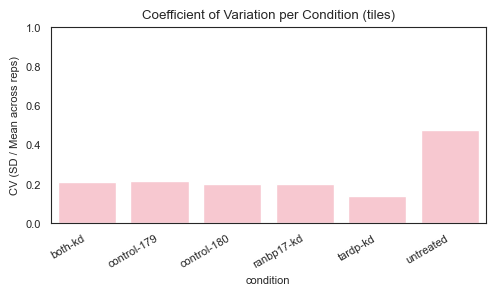

In [53]:
summary_per_rep = (
    df_clean.groupby(['condition', 'batch', 'rep'])['fraction_overlap']
    .mean().reset_index().sort_values(['condition', 'batch', 'rep'])
)
repro_stats = (
    summary_per_rep.groupby('condition')['fraction_overlap']
    .agg(['mean', 'std'])
    .assign(CV=lambda d: d['std'] / d['mean'])
    .reset_index()
)
print(repro_stats)

plt.figure(figsize=(5, 3))
sns.barplot(data=repro_stats, x='condition', y='CV', color='pink')
plt.title('Coefficient of Variation per Condition (tiles)')
plt.ylabel('CV (SD / Mean across reps)')
plt.xticks(rotation=30, ha='right')
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## Reproducibility: means per condition and replicate

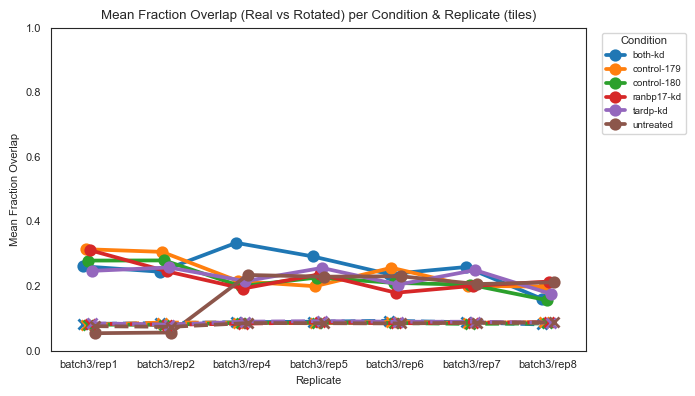

In [54]:
summary = (
    df_clean.groupby(['condition', 'batch', 'rep'])[['fraction_overlap', 'fraction_overlap_rotated']]
    .mean().reset_index()
)
summary['rep'] = summary['batch'].astype(str) + '/' + summary['rep'].astype(str)  # batch x rep unit

plt.figure(figsize=(7, 4))
sns.pointplot(data=summary, x='rep', y='fraction_overlap', hue='condition',
              markers='o', dodge=True, errorbar=None, linestyles='-')
sns.pointplot(data=summary, x='rep', y='fraction_overlap_rotated', hue='condition',
              markers='x', dodge=True, errorbar=None, linestyles='--', legend=False)
plt.title('Mean Fraction Overlap (Real vs Rotated) per Condition & Replicate (tiles)')
plt.ylabel('Mean Fraction Overlap')
plt.xlabel('Replicate')
plt.ylim(0, 1)
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_per_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

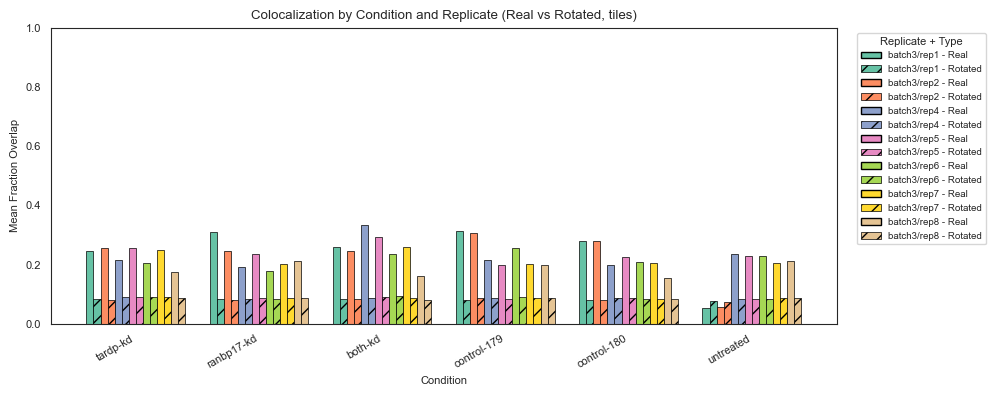

In [55]:
# Bar plot grouped by condition + replicate, Real vs Rotated (hatched).
long_df = pd.melt(summary, id_vars=['condition', 'rep'],
                  value_vars=['fraction_overlap', 'fraction_overlap_rotated'],
                  var_name='type', value_name='overlap')
long_df['type'] = long_df['type'].map({'fraction_overlap': 'Real', 'fraction_overlap_rotated': 'Rotated'})
long_df['rep_type'] = long_df['rep'].astype(str) + '-' + long_df['type']

conds = [c for c in CONDITIONS if c in long_df['condition'].unique()]
rep_order = sorted(long_df['rep'].unique())
base_palette = dict(zip(rep_order, sns.color_palette('Set2', n_colors=len(rep_order))))

plt.figure(figsize=(10, 4))
ax = plt.gca()
rep_type_order = sorted(long_df['rep_type'].unique())
bar_width = 0.8 / len(rep_type_order)
for i, cond in enumerate(conds):
    for j, rep_type in enumerate(rep_type_order):
        r = long_df[(long_df['condition'] == cond) & (long_df['rep_type'] == rep_type)]
        if r.empty:
            continue
        y = r['overlap'].values[0]; rep = r['rep'].values[0]
        is_rotated = 'Rotated' in rep_type
        xpos = i - 0.4 + j * bar_width + bar_width / 2
        ax.bar(xpos, y, width=bar_width, color=base_palette[rep], edgecolor='black',
               hatch='//' if is_rotated else '', linewidth=0.5,
               label=rep_type if i == 0 else None)

ax.set_xticks(range(len(conds)))
ax.set_xticklabels(conds, rotation=30, ha='right')
ax.set_xlabel('Condition'); ax.set_ylabel('Mean Fraction Overlap'); ax.set_ylim(0, 1)
ax.set_title('Colocalization by Condition and Replicate (Real vs Rotated, tiles)')

legend_patches = []
for rep in rep_order:
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', label=f'{rep} - Real'))
    legend_patches.append(mpatches.Patch(facecolor=base_palette[rep], edgecolor='black', hatch='//', label=f'{rep} - Rotated', linewidth=0.5))
ax.legend(handles=legend_patches, title='Replicate + Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(save_path, f'coloc_bars_condition_rep_{ANCHOR_MARKER}_{PARTNER_MARKER}_tiles.png'), dpi=200, bbox_inches='tight')
plt.show()

In [56]:
print('Done!')

Done!
